# Noise Effects in Oculomotor Control

This notebook explores how each of the four sensory noise sources affects different oculomotor
behaviours.  Each source enters the model through a distinct pathway:

| Parameter | Pathway | Primary effect |
|-----------|---------|----------------|
| `sigma_canal` | Canal → VS → NI | Slow gaze drift during fixation; VOR velocity noise |
| `sigma_pos` | Retinal position (OU) → SG accumulator | Microsaccades during fixation; saccade RT and endpoint scatter |
| `sigma_vel` | Retinal velocity → pursuit integrator | Noisy smooth pursuit; reduced steady-state gain |
| `sigma_slip` | Retinal slip → VS (OKR pathway) | Noisy OKR slow-phase velocity |

**Structure:**
1. Fixation — qualitative characterisation of each noise source
2. Saccades — RT and endpoint variability vs. `sigma_pos`
3. Smooth pursuit — gain variability vs. `sigma_vel`
4. VOR — gain variability vs. `sigma_canal`
5. OKR — slow-phase gain variability vs. `sigma_slip`

**Runtime note:** Multi-seed loops in sections 2–5 each run 10–25 short simulations.
Total runtime after JAX JIT warm-up is roughly 5–10 min on CPU.

In [1]:
import sys, os
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from oculomotor.sim.simulator import (
    PARAMS_DEFAULT, with_brain, with_sensory, simulate, SimConfig,
    _IDX_VS, _IDX_NI,
)
from oculomotor.analysis import extract_burst, extract_spv, ax_fmt
from oculomotor import __version__

print(f'oculomotor {__version__}')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

# Disable warmup: all tests start from rest, so zero ICs are already correct.
# The default 3 s warmup in the LLM pipeline handles pre-charged VS and phoria;
# it adds unnecessary compute here.
CFG = SimConfig(warmup_s=0.0)
DT  = 0.001

_C = dict(
    eye='#2166ac', target='#d6604d', vel='#1a9641',
    head='#555555', scene='#1b7837', burst='#f4a582',
    gray='#888888', acc='#e08214',
)

# ── Convenience wrappers ───────────────────────────────────────────────────────

def make_t(T_end):
    return jnp.arange(0.0, T_end, DT)

def eye_yaw_pos(states):
    """Left-eye yaw position (deg) from a SimState trajectory."""
    return np.array(states.plant[:, 0])

def eye_yaw_vel(states):
    """Left-eye yaw velocity by numerical differentiation (deg/s)."""
    return np.gradient(eye_yaw_pos(states), DT)

def run(params, t, key=0, **kw):
    """Simulate and return full states."""
    return simulate(params, t, return_states=True,
                    sim_config=CFG, key=jax.random.PRNGKey(key), **kw)

def detect_rt(eye_vel, t_np, t_step, vel_thresh=30.0, min_delay=0.06):
    """Saccade RT relative to t_step (s), or NaN if not detected."""
    mask = (t_np > t_step + min_delay) & (np.abs(eye_vel) > vel_thresh)
    idx  = int(np.argmax(mask))
    return float(t_np[idx] - t_step) if mask[idx] else float('nan')

def detect_microsaccades(eye_vel, vel_thresh=25.0, min_gap_ms=50):
    """Return sample indices of microsaccade onset (eye velocity crosses threshold)."""
    above = np.abs(eye_vel) > vel_thresh
    ons   = np.where(np.diff(above.astype(int)) > 0)[0] + 1
    if len(ons) <= 1:
        return ons
    keep = [int(ons[0])]
    for i in ons[1:]:
        if int(i) - keep[-1] > min_gap_ms:
            keep.append(int(i))
    return np.array(keep)

oculomotor 2a81269-dirty


---
## 1. Fixation

With the head stationary and a foveal target, ideally the eye should not move at all.
The four noise sources each introduce a different movement signature:

- **Canal noise** — perturbs the VS → NI chain.  VS acts as a low-pass filter, so only
  low-frequency canal noise bleeds through to eye position (slow drift, no saccades).
- **Position drift (OU)** — adds correlated noise to the retinal position error signal.
  When the accumulated drift crosses the SG threshold, a corrective microsaccade fires.
  The OU time constant (`tau_pos_drift = 0.3 s`) controls how fast drift accumulates.
- **Velocity noise** — perturbs the pursuit velocity integrator, producing slow smooth
  drift similar to ocular motor noise observed in pursuit-related pathways.

Each condition uses a single random seed (`key=42`) for reproducibility.

In [2]:
%%time
T_FIX = 4.0
t_fix = make_t(T_FIX)
T     = len(t_fix)
t_np  = np.array(t_fix)

CONDITIONS_FIX = [
    ('Noiseless',          dict(sigma_canal=0.0, sigma_pos=0.0, sigma_vel=0.0)),
    ('Canal  \u03c3=3\u00b0/s',  dict(sigma_canal=3.0, sigma_pos=0.0, sigma_vel=0.0)),
    ('Pos drift  \u03c3=0.3\u00b0', dict(sigma_canal=0.0, sigma_pos=0.3, sigma_vel=0.0)),
    ('Vel noise  \u03c3=5\u00b0/s', dict(sigma_canal=0.0, sigma_pos=0.0, sigma_vel=5.0)),
    ('All combined',       dict(sigma_canal=3.0, sigma_pos=0.3, sigma_vel=5.0)),
]

fix_data = []
for name, noise in CONDITIONS_FIX:
    params = with_sensory(PARAMS_DEFAULT, **noise)
    states = run(params, t_fix, key=42,
                 scene_present_array=jnp.ones(T),
                 target_present_array=jnp.ones(T))
    pos  = eye_yaw_pos(states)
    vel  = eye_yaw_vel(states)
    msac = detect_microsaccades(vel)
    fix_data.append(dict(name=name, pos=pos, vel=vel, msac=msac))
    print(f'  {name:25s}  pos_std={pos.std():.3f}\u00b0   microsaccades={len(msac)}')

  Noiseless                  pos_std=0.402°   microsaccades=0
  Canal  σ=3°/s              pos_std=0.401°   microsaccades=0
  Pos drift  σ=0.3°          pos_std=0.410°   microsaccades=0
  Vel noise  σ=5°/s          pos_std=0.362°   microsaccades=0
  All combined               pos_std=0.411°   microsaccades=1
CPU times: total: 56.3 s
Wall time: 23.9 s


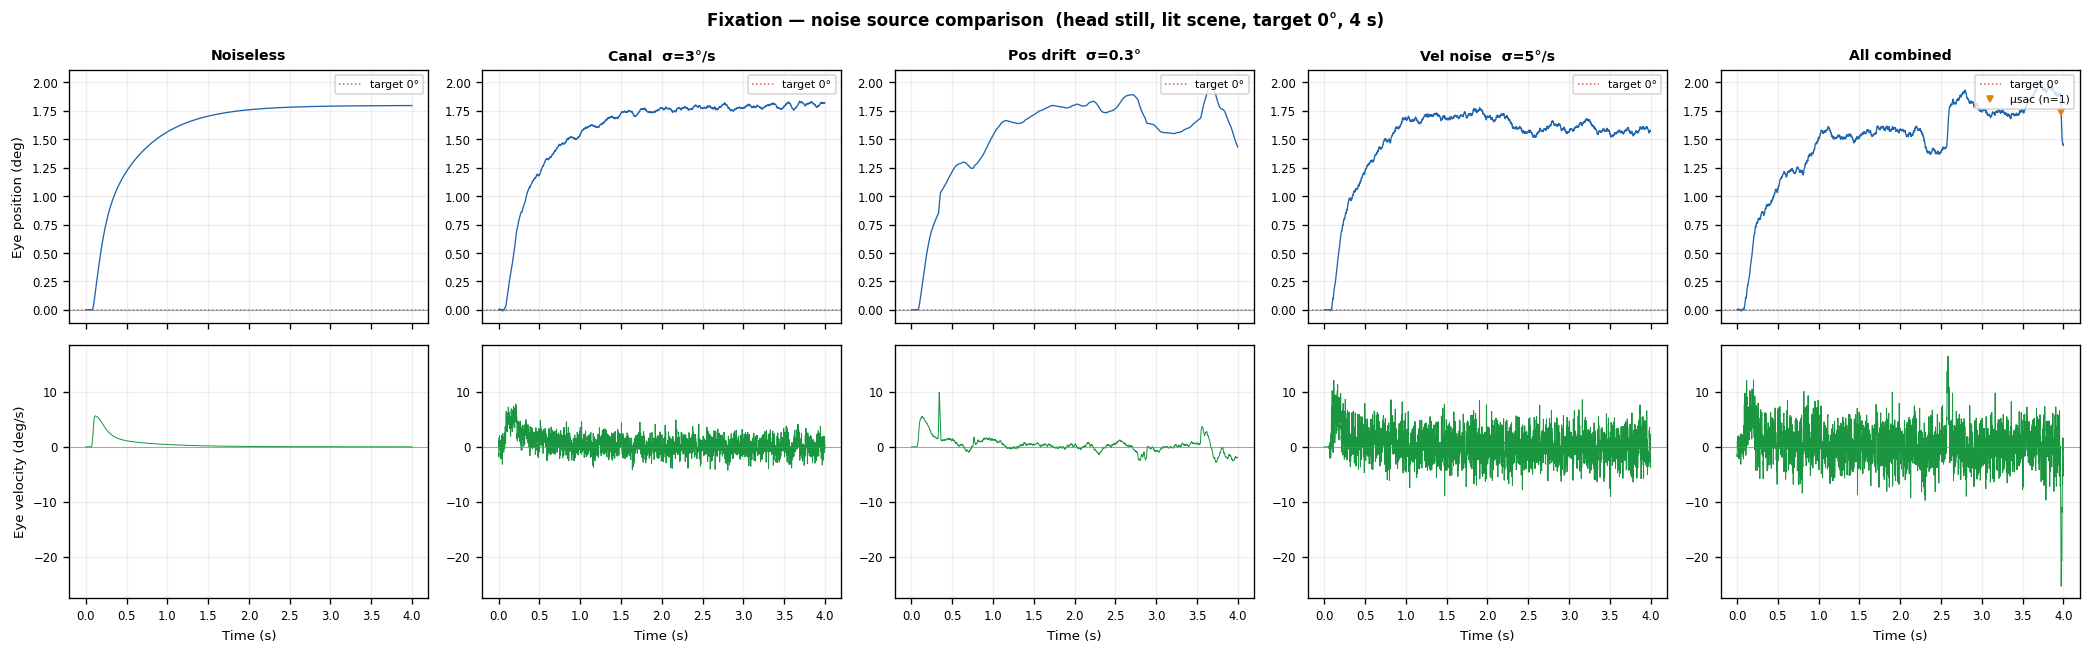

In [3]:
n_cond = len(CONDITIONS_FIX)
fig, axes = plt.subplots(2, n_cond, figsize=(3.5 * n_cond, 5.5), sharex=True)
fig.suptitle('Fixation \u2014 noise source comparison  (head still, lit scene, target 0\u00b0, 4 s)',
             fontsize=10, fontweight='bold')

for ci, d in enumerate(fix_data):
    axes[0, ci].set_title(d['name'], fontsize=8.5, fontweight='bold')

    # Row 0: eye position
    axes[0, ci].axhline(0, color=_C['target'], lw=0.9, ls=':', label='target 0\u00b0')
    axes[0, ci].plot(t_np, d['pos'], color=_C['eye'], lw=0.8)
    if len(d['msac']):
        axes[0, ci].plot(t_np[d['msac']], d['pos'][d['msac']], 'v',
                         color=_C['acc'], ms=4, zorder=5,
                         label=f'\u03bcsac (n={len(d["msac"])})')
    ax_fmt(axes[0, ci])
    if ci == 0:
        axes[0, ci].set_ylabel('Eye position (deg)', fontsize=8)
    axes[0, ci].legend(fontsize=6.5, loc='upper right')

    # Row 1: eye velocity
    axes[1, ci].plot(t_np, d['vel'], color=_C['vel'], lw=0.6)
    ax_fmt(axes[1, ci])
    axes[1, ci].set_xlabel('Time (s)', fontsize=8)
    if ci == 0:
        axes[1, ci].set_ylabel('Eye velocity (deg/s)', fontsize=8)

# Equalize rows
for row, min_span in [(0, 0.4), (1, 5.0)]:
    lo = min(ax.get_ylim()[0] for ax in axes[row])
    hi = max(ax.get_ylim()[1] for ax in axes[row])
    span = max(hi - lo, min_span)
    mid  = (lo + hi) / 2
    for ax in axes[row]:
        ax.set_ylim(mid - span / 2, mid + span / 2)

fig.tight_layout()
plt.show()

---
## 2. Saccades \u2014 reaction time and endpoint variability

The retinal position noise (`sigma_pos`) is the primary source of saccade variability.
It enters through an Ornstein\u2013Uhlenbeck process that adds correlated noise to the
delayed position error `pos_delayed`, which feeds the saccade accumulator.

Two effects are predicted:

1. **RT variability** \u2014 if the OU drift is in the same direction as the target at the
   moment of the step, the accumulator pre-charges and fires sooner (short RT).  If it
   opposes the target, the accumulator charges more slowly (long RT).

2. **Endpoint scatter** \u2014 the saccade vector is computed from `e_held`, a sample of
   the noisy position error at saccade onset.  Noise in `e_held` directly translates to
   undershoot or overshoot.

Simulation: 10\u00b0 target step at t = 0.1 s, n = 25 seeds per `sigma_pos` level.

In [4]:
%%time
AMP     = 10.0    # target amplitude (deg)
T_JUMP  = 0.1     # target step time (s)
T_END   = 1.1     # trial duration
N_SEEDS = 25

SIGMA_POS_LEVELS = [0.0, 0.2, 0.5]   # deg

t_sac = make_t(T_END)
T     = len(t_sac)
t_np  = np.array(t_sac)

pt3 = np.zeros((T, 3)); pt3[:, 2] = 1.0
pt3[t_np >= T_JUMP, 0] = np.tan(np.radians(AMP))
pt3 = jnp.array(pt3)

sac_data = {}
for sp in SIGMA_POS_LEVELS:
    params = with_sensory(PARAMS_DEFAULT, sigma_pos=sp)
    rts, endpoints, traces = [], [], []
    for seed in range(N_SEEDS):
        states = run(params, t_sac, key=seed,
                     p_target_array=pt3,
                     scene_present_array=jnp.ones(T))
        pos = eye_yaw_pos(states)
        vel = eye_yaw_vel(states)
        rts.append(detect_rt(vel, t_np, T_JUMP))
        endpoints.append(float(np.mean(pos[t_np > 0.7])))
        traces.append(pos)
        del states
        if (seed + 1) % 5 == 0:
            print(f'  sigma_pos={sp:.1f}: {seed+1}/{N_SEEDS}', end='  ', flush=True)
    print()
    rts_ms = np.array(rts) * 1e3
    eps    = np.array(endpoints)
    sac_data[sp] = dict(rts_ms=rts_ms, endpoints=eps, traces=np.array(traces))
    print(f'  -> RT = {np.nanmean(rts_ms):.0f} \u00b1 {np.nanstd(rts_ms):.0f} ms'
          f'   endpoint = {eps.mean():.2f} \u00b1 {eps.std():.2f}\u00b0')

  sigma_pos=0.0: 5/25    sigma_pos=0.0: 10/25    sigma_pos=0.0: 15/25    sigma_pos=0.0: 20/25    sigma_pos=0.0: 25/25  
  -> RT = 101 ± 0 ms   endpoint = 11.35 ± 0.00°
  sigma_pos=0.2: 5/25    sigma_pos=0.2: 10/25    sigma_pos=0.2: 15/25    sigma_pos=0.2: 20/25    sigma_pos=0.2: 25/25  
  -> RT = 100 ± 1 ms   endpoint = 11.36 ± 0.19°
  sigma_pos=0.5: 5/25    sigma_pos=0.5: 10/25    sigma_pos=0.5: 15/25    sigma_pos=0.5: 20/25    sigma_pos=0.5: 25/25  
  -> RT = 177 ± 127 ms   endpoint = 11.43 ± 0.39°
CPU times: total: 1min 6s
Wall time: 31.4 s


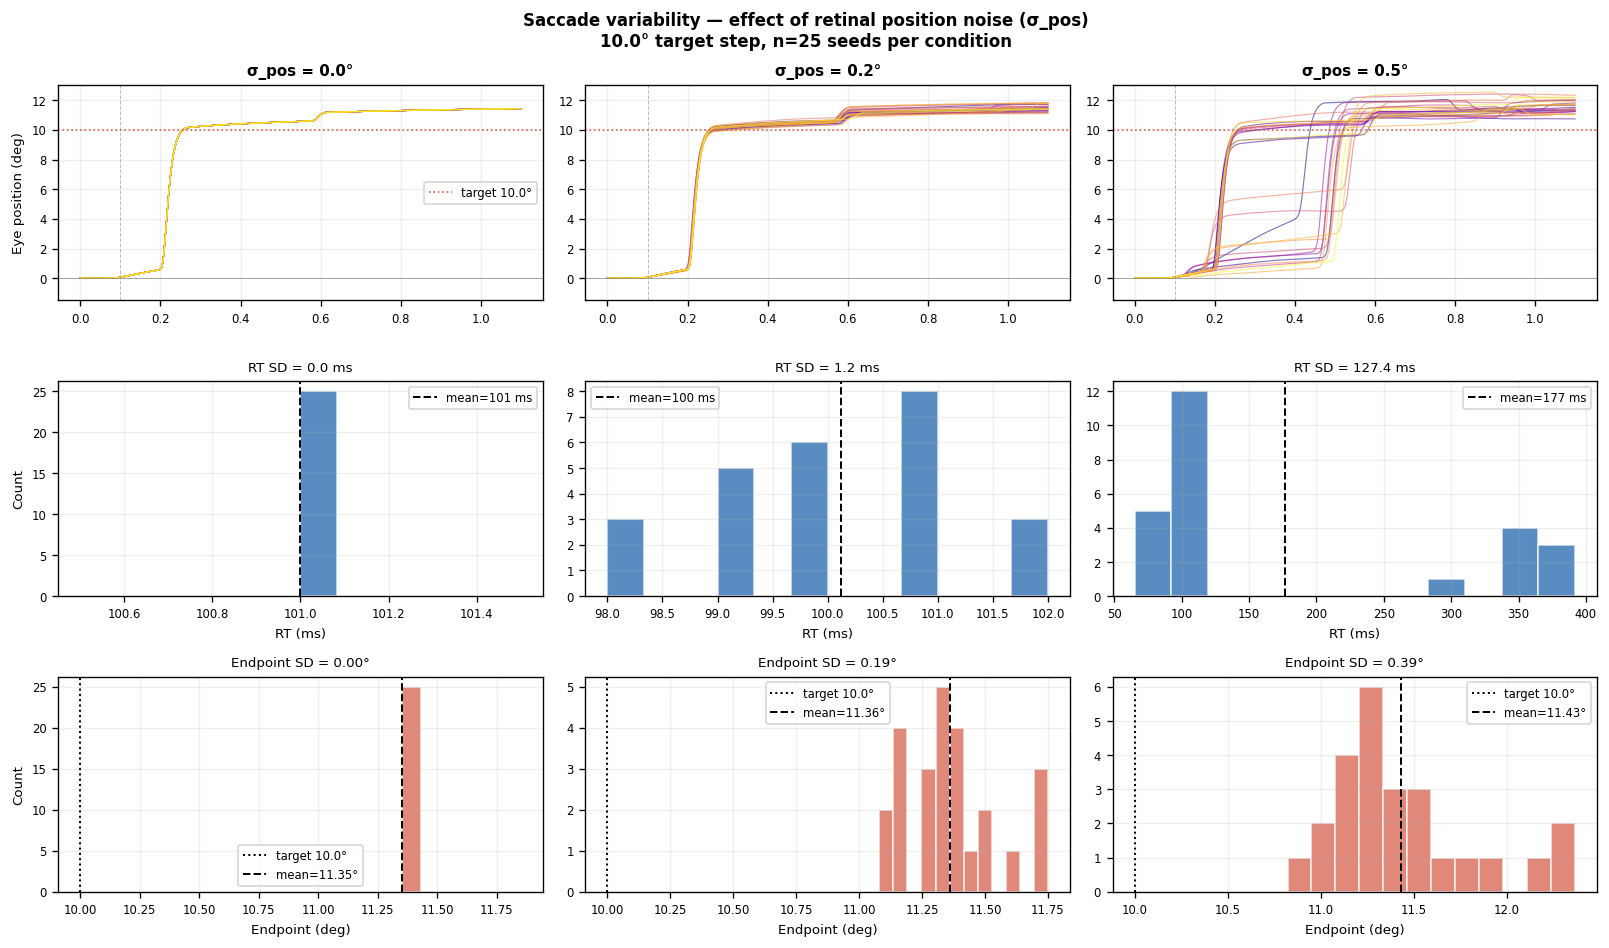


 sigma_pos |   RT mean |   RT SD |   EP mean |   EP SD
-------------------------------------------------------
      0.00°|      101ms|      0ms|    11.35° |  0.00°
      0.20°|      100ms|      1ms|    11.36° |  0.19°
      0.50°|      177ms|    127ms|    11.43° |  0.39°


In [5]:
n_levels = len(SIGMA_POS_LEVELS)
fig, axes = plt.subplots(3, n_levels, figsize=(4.5 * n_levels, 8))
fig.suptitle(f'Saccade variability \u2014 effect of retinal position noise (\u03c3_pos)\n'
             f'{AMP}\u00b0 target step, n={N_SEEDS} seeds per condition',
             fontsize=10, fontweight='bold')

cmap = plt.get_cmap('plasma')
rng  = np.random.default_rng(0)

for ci, sp in enumerate(SIGMA_POS_LEVELS):
    d = sac_data[sp]
    axes[0, ci].set_title(f'\u03c3_pos = {sp:.1f}\u00b0', fontsize=9, fontweight='bold')

    # Row 0: eye position traces
    for si in range(N_SEEDS):
        axes[0, ci].plot(t_np, d['traces'][si],
                         color=cmap(si / max(N_SEEDS - 1, 1)), lw=0.7, alpha=0.55)
    axes[0, ci].axhline(AMP, color=_C['target'], lw=1.0, ls=':', label=f'target {AMP}\u00b0')
    axes[0, ci].axvline(T_JUMP, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_fmt(axes[0, ci])
    axes[0, ci].set_ylim(-1.5, AMP * 1.3)
    if ci == 0:
        axes[0, ci].set_ylabel('Eye position (deg)', fontsize=8)
        axes[0, ci].legend(fontsize=7)

    # Row 1: RT distribution
    valid_rt = d['rts_ms'][~np.isnan(d['rts_ms'])]
    axes[1, ci].hist(valid_rt, bins=12, color=_C['eye'], alpha=0.75, edgecolor='white')
    axes[1, ci].axvline(np.nanmean(d['rts_ms']), color='k', lw=1.2, ls='--',
                        label=f'mean={np.nanmean(d["rts_ms"]):.0f} ms')
    axes[1, ci].set_xlabel('RT (ms)', fontsize=8)
    if ci == 0:
        axes[1, ci].set_ylabel('Count', fontsize=8)
    axes[1, ci].legend(fontsize=7)
    axes[1, ci].grid(True, alpha=0.2)
    axes[1, ci].tick_params(labelsize=7)
    axes[1, ci].set_title(f'RT SD = {np.nanstd(d["rts_ms"]):.1f} ms', fontsize=8)

    # Row 2: Endpoint distribution
    axes[2, ci].hist(d['endpoints'], bins=12, color=_C['target'], alpha=0.75, edgecolor='white')
    axes[2, ci].axvline(AMP, color='k', lw=1.2, ls=':', label=f'target {AMP}\u00b0')
    axes[2, ci].axvline(d['endpoints'].mean(), color='k', lw=1.2, ls='--',
                        label=f'mean={d["endpoints"].mean():.2f}\u00b0')
    axes[2, ci].set_xlabel('Endpoint (deg)', fontsize=8)
    if ci == 0:
        axes[2, ci].set_ylabel('Count', fontsize=8)
    axes[2, ci].legend(fontsize=7)
    axes[2, ci].grid(True, alpha=0.2)
    axes[2, ci].tick_params(labelsize=7)
    axes[2, ci].set_title(f'Endpoint SD = {d["endpoints"].std():.2f}\u00b0', fontsize=8)

fig.tight_layout()
plt.show()

# Summary
print(f'\n{"sigma_pos":>10} | {"RT mean":>9} | {"RT SD":>7} | {"EP mean":>9} | {"EP SD":>7}')
print('-' * 55)
for sp in SIGMA_POS_LEVELS:
    d = sac_data[sp]
    print(f'{sp:>10.2f}\u00b0| {np.nanmean(d["rts_ms"]):>8.0f}ms| '
          f'{np.nanstd(d["rts_ms"]):>6.0f}ms| '
          f'{d["endpoints"].mean():>8.2f}\u00b0 | {d["endpoints"].std():>5.2f}\u00b0')

---
## 3. Smooth Pursuit \u2014 gain variability

The velocity noise (`sigma_vel`) directly perturbs the retinal velocity error signal
that drives the pursuit integrator.  The pursuit integrator is a leaky integrator
with a Smith predictor; velocity noise therefore produces:

- Noisy steady-state pursuit velocity (the integrator is continuously driven by noisy input)
- Reduced apparent steady-state gain at high noise levels (noise-driven integrator
  fluctuations cause more corrective saccades, reducing the slow-phase mean)

Simulation: 20\u00b0/s ramp target from t = 0.2 s, n = 15 seeds per `sigma_vel` level.

In [6]:
%%time
TARGET_VEL = 20.0   # deg/s
T_JUMP_P   = 0.2    # ramp onset (s)
T_END_P    = 3.0
N_P        = 15

SIGMA_VEL_LEVELS = [0.0, 3.0, 8.0]   # deg/s

t_pur = make_t(T_END_P)
T     = len(t_pur)
t_np  = np.array(t_pur)

target_deg = np.where(t_np >= T_JUMP_P, TARGET_VEL * (t_np - T_JUMP_P), 0.0)
pt3 = jnp.stack([
    jnp.array(np.tan(np.radians(target_deg)).astype(np.float32)),
    jnp.zeros(T), jnp.ones(T),
], axis=1)
vt3 = jnp.stack([
    jnp.array(np.where(t_np >= T_JUMP_P, TARGET_VEL, 0.0).astype(np.float32)),
    jnp.zeros(T), jnp.zeros(T),
], axis=1)

pur_data = {}
for sv in SIGMA_VEL_LEVELS:
    params = with_sensory(PARAMS_DEFAULT, sigma_vel=sv)
    vel_traces, gains = [], []
    for seed in range(N_P):
        states = run(params, t_pur, key=seed,
                     p_target_array=pt3, v_target_array=vt3,
                     scene_present_array=jnp.ones(T),
                     target_present_array=jnp.ones(T))
        # Use extract_burst to get fast phases, then SPV for gain
        burst  = extract_burst(states, params)[:, 0]
        vel    = eye_yaw_vel(states)
        spv    = extract_spv(t_np, vel, burst)
        steady = spv[(t_np >= 1.5) & (t_np <= 2.5)]
        gains.append(float(np.mean(steady) / TARGET_VEL))
        vel_traces.append(vel)
        del states
    pur_data[sv] = dict(vel_traces=np.array(vel_traces), gains=np.array(gains))
    print(f'  sigma_vel={sv:.0f}\u00b0/s:  gain = {np.mean(gains):.3f} \u00b1 {np.std(gains):.3f}')

  sigma_vel=0°/s:  gain = 0.921 ± 0.000
  sigma_vel=3°/s:  gain = 0.922 ± 0.010
  sigma_vel=8°/s:  gain = 0.920 ± 0.018
CPU times: total: 1min 25s
Wall time: 41.9 s


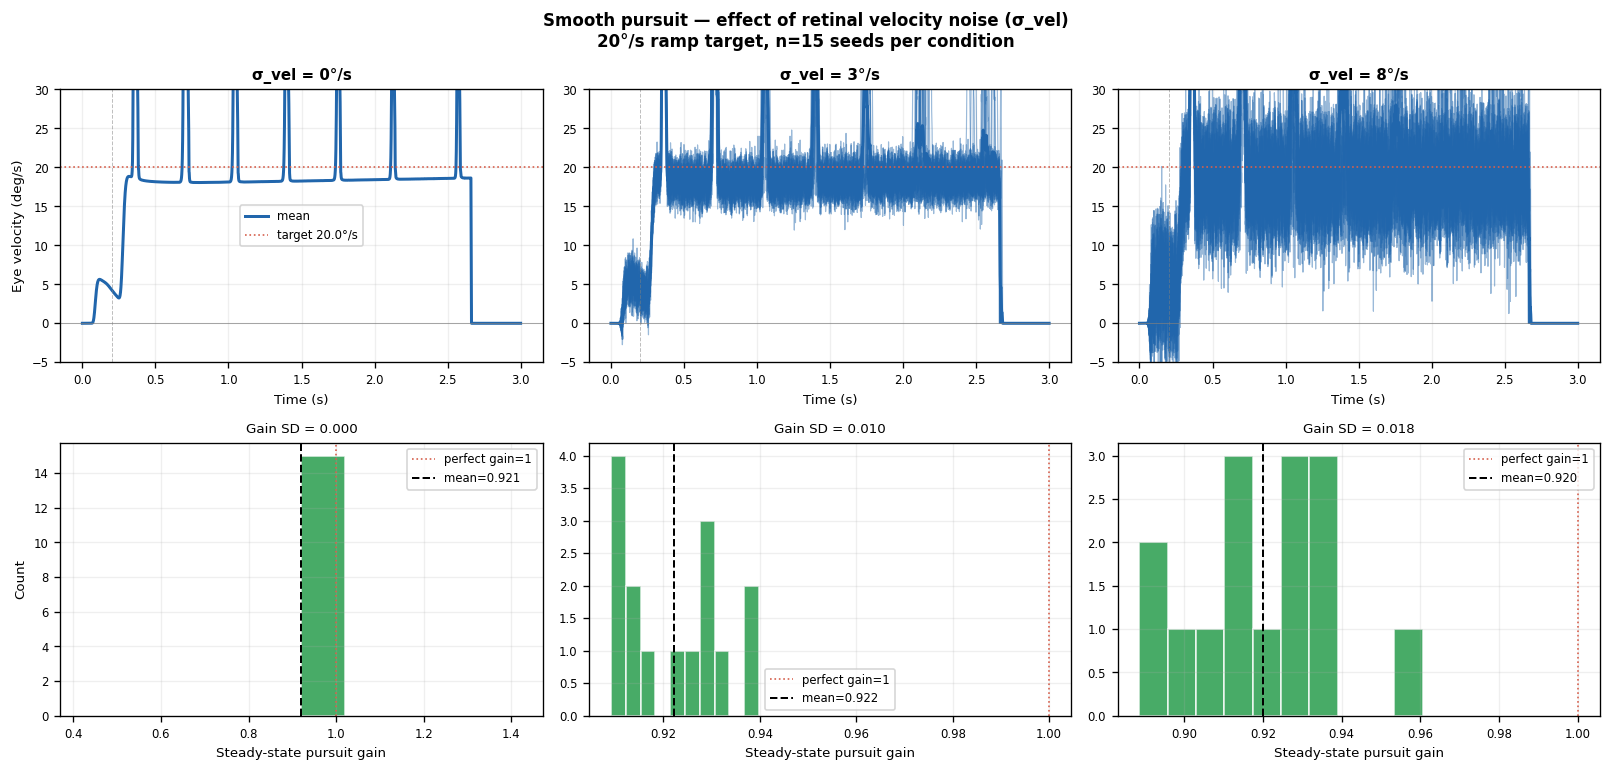

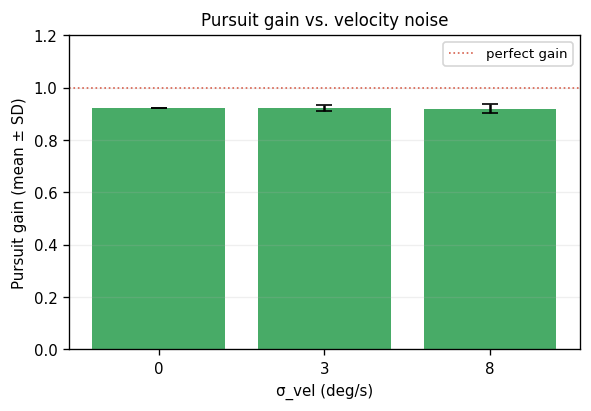

In [7]:
n_lv = len(SIGMA_VEL_LEVELS)
fig, axes = plt.subplots(2, n_lv, figsize=(4.5 * n_lv, 6.5))
fig.suptitle('Smooth pursuit \u2014 effect of retinal velocity noise (\u03c3_vel)\n'
             f'20\u00b0/s ramp target, n={N_P} seeds per condition',
             fontsize=10, fontweight='bold')

for ci, sv in enumerate(SIGMA_VEL_LEVELS):
    d = pur_data[sv]
    axes[0, ci].set_title(f'\u03c3_vel = {sv:.0f}\u00b0/s', fontsize=9, fontweight='bold')

    # Row 0: eye velocity traces
    for si in range(N_P):
        axes[0, ci].plot(t_np, d['vel_traces'][si], color=_C['eye'], lw=0.7, alpha=0.45)
    mean_vel = d['vel_traces'].mean(axis=0)
    axes[0, ci].plot(t_np, mean_vel, color=_C['eye'], lw=1.8, label='mean')
    axes[0, ci].axhline(TARGET_VEL, color=_C['target'], lw=1.0, ls=':',
                        label=f'target {TARGET_VEL}\u00b0/s')
    axes[0, ci].axvline(T_JUMP_P, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_fmt(axes[0, ci])
    axes[0, ci].set_ylim(-5, TARGET_VEL * 1.5)
    if ci == 0:
        axes[0, ci].set_ylabel('Eye velocity (deg/s)', fontsize=8)
        axes[0, ci].legend(fontsize=7)
    axes[0, ci].set_xlabel('Time (s)', fontsize=8)

    # Row 1: gain distribution
    axes[1, ci].hist(d['gains'], bins=10, color=_C['vel'], alpha=0.8, edgecolor='white')
    axes[1, ci].axvline(1.0, color=_C['target'], lw=1.0, ls=':', label='perfect gain=1')
    axes[1, ci].axvline(d['gains'].mean(), color='k', lw=1.2, ls='--',
                        label=f'mean={d["gains"].mean():.3f}')
    axes[1, ci].set_xlabel('Steady-state pursuit gain', fontsize=8)
    if ci == 0:
        axes[1, ci].set_ylabel('Count', fontsize=8)
    axes[1, ci].legend(fontsize=7)
    axes[1, ci].grid(True, alpha=0.2)
    axes[1, ci].tick_params(labelsize=7)
    axes[1, ci].set_title(f'Gain SD = {d["gains"].std():.3f}', fontsize=8)

fig.tight_layout()
plt.show()

# Summary bar plot
fig2, ax = plt.subplots(figsize=(5, 3.5))
means = [pur_data[sv]['gains'].mean() for sv in SIGMA_VEL_LEVELS]
sds   = [pur_data[sv]['gains'].std()  for sv in SIGMA_VEL_LEVELS]
x     = np.arange(n_lv)
ax.bar(x, means, yerr=sds, color=_C['vel'], alpha=0.8, capsize=5, error_kw=dict(lw=1.5))
ax.axhline(1.0, color=_C['target'], lw=1.0, ls=':', label='perfect gain')
ax.set_xticks(x)
ax.set_xticklabels([f'{sv:.0f}' for sv in SIGMA_VEL_LEVELS])
ax.set_xlabel('\u03c3_vel (deg/s)', fontsize=9)
ax.set_ylabel('Pursuit gain (mean \u00b1 SD)', fontsize=9)
ax.set_title('Pursuit gain vs. velocity noise', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')
ax.set_ylim(0, 1.2)
fig2.tight_layout()
plt.show()

---
## 4. VOR \u2014 gain variability with canal noise

Canal noise (`sigma_canal`) directly perturbs the afferent signals from the six
semicircular canals.  These signals are the primary drive for the VOR, so canal
noise adds variability to the compensatory eye velocity.

Unlike the VS pathway (which low-pass filters canal noise and reduces its effect
on steady-state fixation), the VOR fast pathway passes canal signals with little
delay.  Canal noise therefore directly contaminates the eye velocity trace.

VOR gain is measured during the initial phase (0.5\u20132.5 s) of a 30\u00b0/s constant
rotation, before canal adaptation substantially reduces the response.
Saccades are disabled (`g_burst = 0`) for a clean velocity measurement.

Simulation: 30\u00b0/s head step for 3 s, in the dark (no scene), n = 15 seeds.

In [8]:
%%time
HEAD_VEL    = 30.0   # deg/s
T_ROT       = 3.0    # rotation duration (s)
T_END_V     = 5.0    # total (includes coast)
N_V         = 15

SIGMA_CANAL_LEVELS = [0.0, 1.5, 4.0]   # deg/s

t_vor = make_t(T_END_V)
T     = len(t_vor)
t_np  = np.array(t_vor)

hv_np = np.where(t_np < T_ROT, HEAD_VEL, 0.0).astype(np.float32)
hv3   = jnp.stack([jnp.array(hv_np), jnp.zeros(T), jnp.zeros(T)], axis=1)

# No saccades: cleaner VOR gain measurement
params_vor_base = with_brain(PARAMS_DEFAULT, g_burst=0.0)

vor_data = {}
for sc in SIGMA_CANAL_LEVELS:
    params = with_sensory(params_vor_base, sigma_canal=sc)
    vel_traces, gains = [], []
    for seed in range(N_V):
        states = run(params, t_vor, key=seed, head_vel_array=hv3)
        vel    = eye_yaw_vel(states)
        # VOR gain: |mean eye_vel| / head_vel in 0.5-2.5 s window
        mask_g = (t_np >= 0.5) & (t_np <= 2.5)
        gains.append(float(np.abs(np.mean(vel[mask_g])) / HEAD_VEL))
        vel_traces.append(vel)
        del states
    vor_data[sc] = dict(vel_traces=np.array(vel_traces), gains=np.array(gains))
    print(f'  sigma_canal={sc:.1f}\u00b0/s:  VOR gain = {np.mean(gains):.3f} \u00b1 {np.std(gains):.3f}')

  sigma_canal=0.0°/s:  VOR gain = 0.607 ± 0.000
  sigma_canal=1.5°/s:  VOR gain = 0.607 ± 0.000
  sigma_canal=4.0°/s:  VOR gain = 0.608 ± 0.001
CPU times: total: 1min 48s
Wall time: 50.6 s


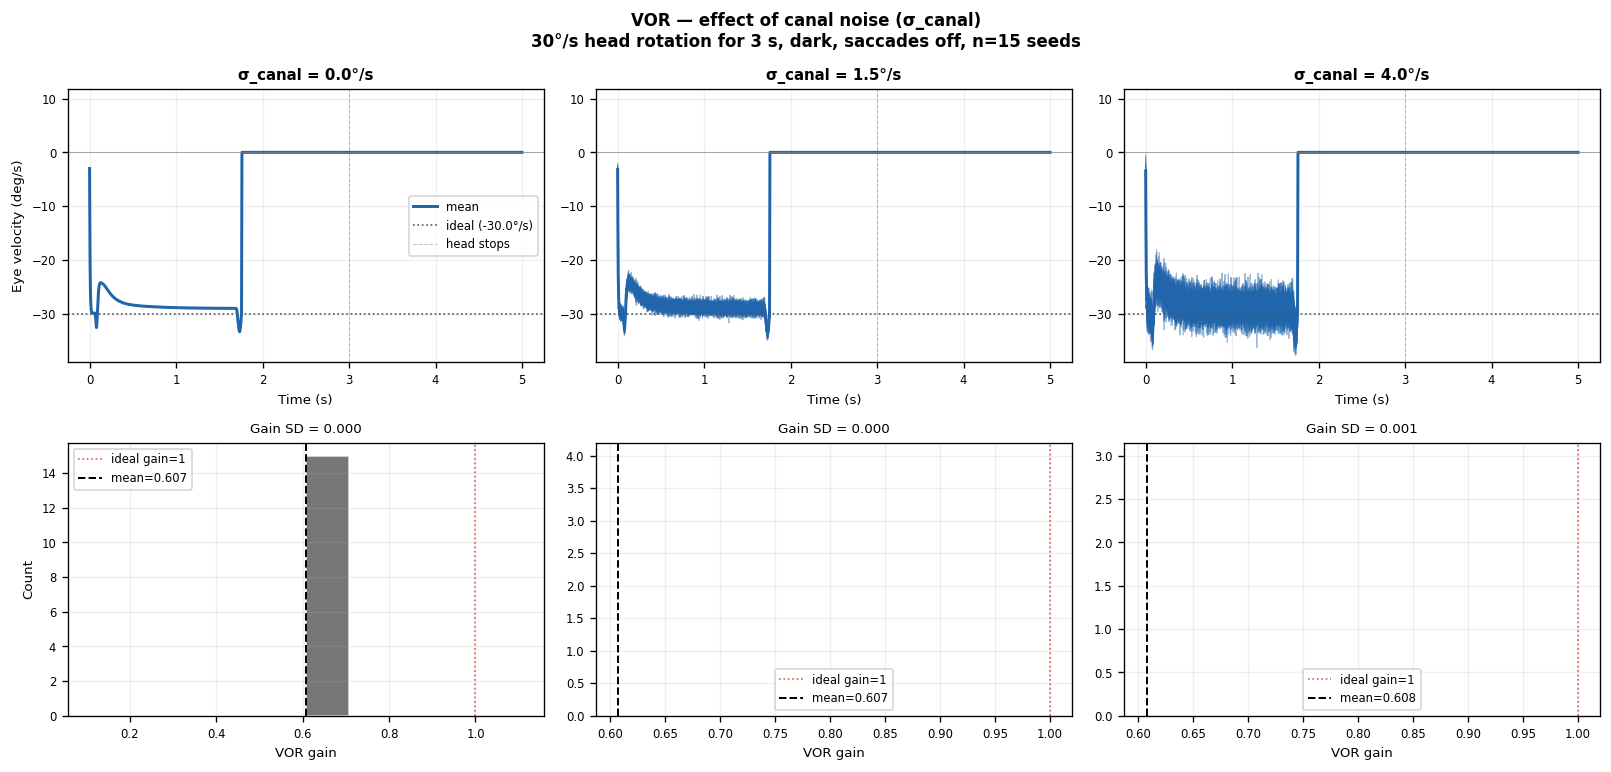

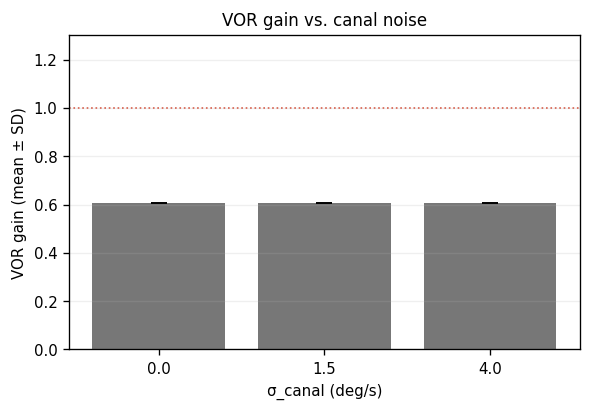

In [9]:
n_lv = len(SIGMA_CANAL_LEVELS)
fig, axes = plt.subplots(2, n_lv, figsize=(4.5 * n_lv, 6.5))
fig.suptitle('VOR \u2014 effect of canal noise (\u03c3_canal)\n'
             f'30\u00b0/s head rotation for 3 s, dark, saccades off, n={N_V} seeds',
             fontsize=10, fontweight='bold')

for ci, sc in enumerate(SIGMA_CANAL_LEVELS):
    d = vor_data[sc]
    axes[0, ci].set_title(f'\u03c3_canal = {sc:.1f}\u00b0/s', fontsize=9, fontweight='bold')

    for si in range(N_V):
        axes[0, ci].plot(t_np, d['vel_traces'][si], color=_C['eye'], lw=0.7, alpha=0.45)
    axes[0, ci].plot(t_np, d['vel_traces'].mean(axis=0), color=_C['eye'], lw=1.8, label='mean')
    axes[0, ci].axhline(-HEAD_VEL, color=_C['head'], lw=1.0, ls=':',
                        label=f'ideal ({-HEAD_VEL}\u00b0/s)')
    axes[0, ci].axvline(T_ROT, color='gray', lw=0.6, ls='--', alpha=0.5, label='head stops')
    ax_fmt(axes[0, ci])
    ylim = max(HEAD_VEL * 1.3, 10.0)
    axes[0, ci].set_ylim(-ylim, ylim * 0.3)
    if ci == 0:
        axes[0, ci].set_ylabel('Eye velocity (deg/s)', fontsize=8)
        axes[0, ci].legend(fontsize=7)
    axes[0, ci].set_xlabel('Time (s)', fontsize=8)

    axes[1, ci].hist(d['gains'], bins=10, color=_C['head'], alpha=0.8, edgecolor='white')
    axes[1, ci].axvline(1.0, color=_C['target'], lw=1.0, ls=':', label='ideal gain=1')
    axes[1, ci].axvline(d['gains'].mean(), color='k', lw=1.2, ls='--',
                        label=f'mean={d["gains"].mean():.3f}')
    axes[1, ci].set_xlabel('VOR gain', fontsize=8)
    if ci == 0:
        axes[1, ci].set_ylabel('Count', fontsize=8)
    axes[1, ci].legend(fontsize=7)
    axes[1, ci].grid(True, alpha=0.2)
    axes[1, ci].tick_params(labelsize=7)
    axes[1, ci].set_title(f'Gain SD = {d["gains"].std():.3f}', fontsize=8)

fig.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(5, 3.5))
means = [vor_data[sc]['gains'].mean() for sc in SIGMA_CANAL_LEVELS]
sds   = [vor_data[sc]['gains'].std()  for sc in SIGMA_CANAL_LEVELS]
x     = np.arange(n_lv)
ax.bar(x, means, yerr=sds, color=_C['head'], alpha=0.8, capsize=5, error_kw=dict(lw=1.5))
ax.axhline(1.0, color=_C['target'], lw=1.0, ls=':')
ax.set_xticks(x)
ax.set_xticklabels([f'{sc:.1f}' for sc in SIGMA_CANAL_LEVELS])
ax.set_xlabel('\u03c3_canal (deg/s)', fontsize=9)
ax.set_ylabel('VOR gain (mean \u00b1 SD)', fontsize=9)
ax.set_title('VOR gain vs. canal noise', fontsize=10)
ax.set_ylim(0, 1.3)
ax.grid(True, alpha=0.2, axis='y')
fig2.tight_layout()
plt.show()

---
## 5. OKR \u2014 slow-phase gain variability with slip noise

Retinal slip noise (`sigma_slip`) perturbs the slip signal that drives
velocity storage (OKR pathway).  During constant full-field scene motion,
VS integrates the slip drive toward a steady state where eye velocity
approximately matches scene velocity (gain \u2248 1).

Slip noise adds variability to the VS trajectory and hence to the
slow-phase eye velocity.  The mean gain should be preserved (noise is
zero-mean), but the SD increases with `sigma_slip`.

Saccades are disabled (`g_burst = 0`) so that the smooth OKR component
is directly visible without separating fast phases.
Gain is measured in the pseudo-steady-state window t = 8\u201312 s
(VS is \u224850\u201360% of full steady state at 10 s given \u03c4_vs \u2248 20 s).

Simulation: 20\u00b0/s constant scene velocity for 15 s, n = 10 seeds.

In [10]:
%%time
SCENE_VEL      = 20.0   # deg/s
T_END_O        = 15.0
N_O            = 10

SIGMA_SLIP_LEVELS = [0.0, 1.5, 4.0]   # deg/s

t_okr = make_t(T_END_O)
T     = len(t_okr)
t_np  = np.array(t_okr)

# 1-D scene velocity; simulator pads to 3-D internally
vs_1d = jnp.full(T, float(SCENE_VEL))

# No saccades: isolate the smooth OKR slow phase
params_okr_base = with_brain(PARAMS_DEFAULT, g_burst=0.0)

okr_data = {}
for sl in SIGMA_SLIP_LEVELS:
    params = with_sensory(params_okr_base, sigma_slip=sl)
    vel_traces, gains = [], []
    for seed in range(N_O):
        states = run(params, t_okr, key=seed, v_scene_array=vs_1d)
        vel    = eye_yaw_vel(states)
        mask_g = (t_np >= 8.0) & (t_np <= 12.0)
        gains.append(float(np.mean(vel[mask_g]) / SCENE_VEL))
        vel_traces.append(vel)
        del states
    okr_data[sl] = dict(vel_traces=np.array(vel_traces), gains=np.array(gains))
    print(f'  sigma_slip={sl:.1f}\u00b0/s:  OKR gain = {np.mean(gains):.3f} \u00b1 {np.std(gains):.3f}')

  sigma_slip=0.0°/s:  OKR gain = 0.006 ± 0.000
  sigma_slip=1.5°/s:  OKR gain = 0.007 ± 0.000
  sigma_slip=4.0°/s:  OKR gain = 0.007 ± 0.000
CPU times: total: 2min 47s
Wall time: 1min 19s


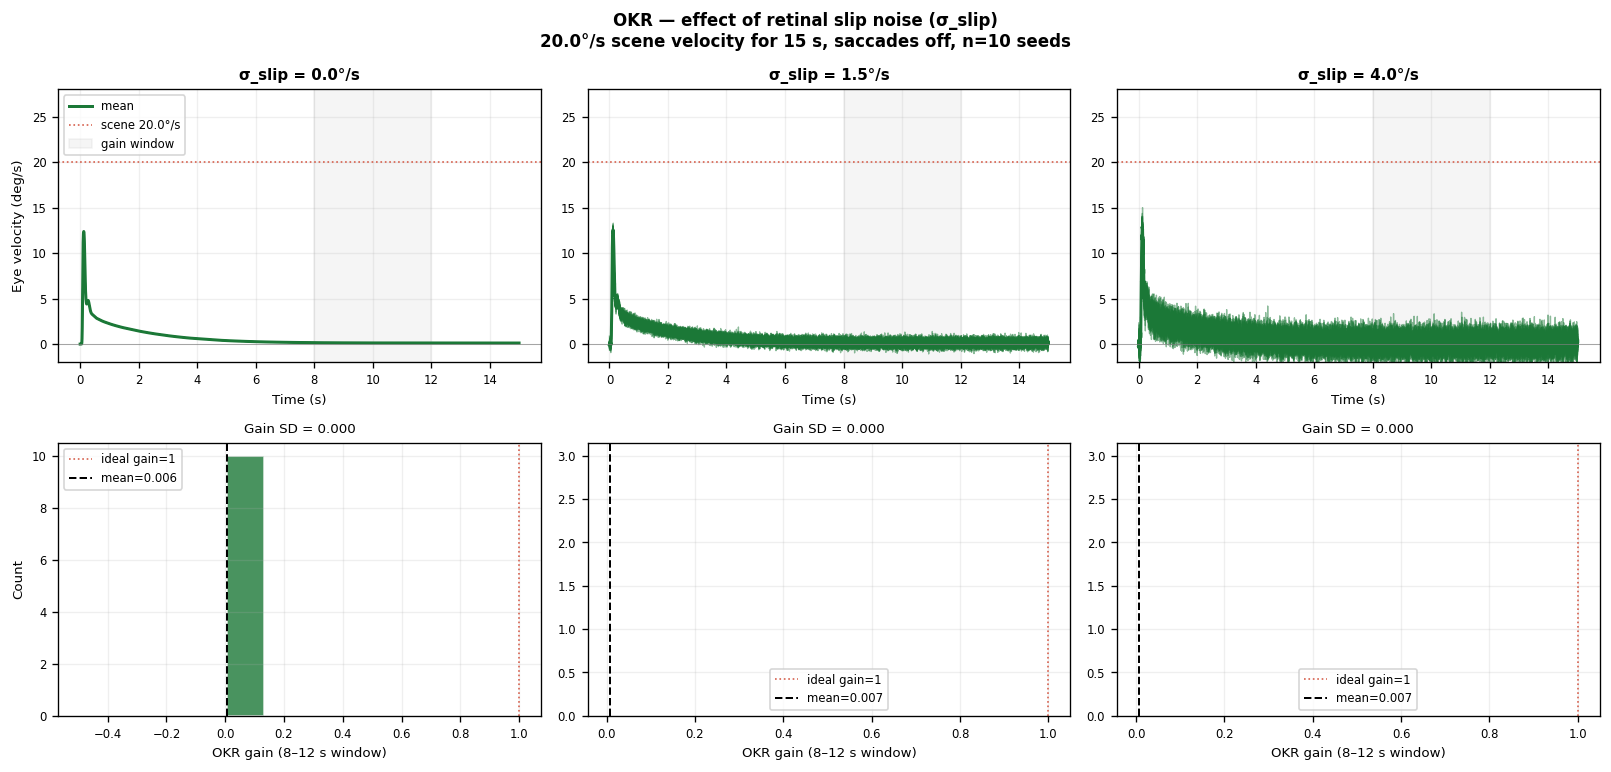

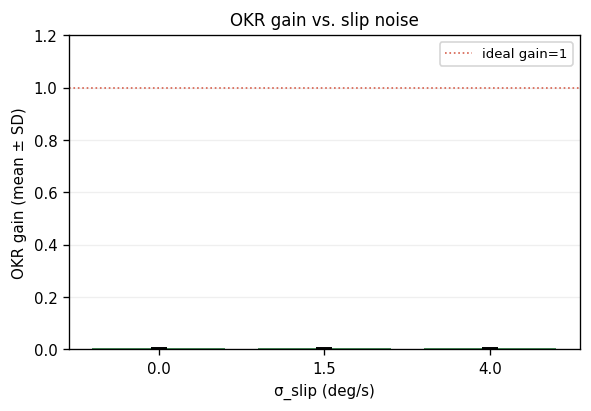

In [11]:
n_lv = len(SIGMA_SLIP_LEVELS)
fig, axes = plt.subplots(2, n_lv, figsize=(4.5 * n_lv, 6.5))
fig.suptitle('OKR \u2014 effect of retinal slip noise (\u03c3_slip)\n'
             f'{SCENE_VEL}\u00b0/s scene velocity for 15 s, saccades off, n={N_O} seeds',
             fontsize=10, fontweight='bold')

for ci, sl in enumerate(SIGMA_SLIP_LEVELS):
    d = okr_data[sl]
    axes[0, ci].set_title(f'\u03c3_slip = {sl:.1f}\u00b0/s', fontsize=9, fontweight='bold')

    for si in range(N_O):
        axes[0, ci].plot(t_np, d['vel_traces'][si], color=_C['scene'], lw=0.8, alpha=0.5)
    axes[0, ci].plot(t_np, d['vel_traces'].mean(axis=0), color=_C['scene'], lw=1.8, label='mean')
    axes[0, ci].axhline(SCENE_VEL, color=_C['target'], lw=1.0, ls=':',
                        label=f'scene {SCENE_VEL}\u00b0/s')
    # Shade the gain measurement window
    axes[0, ci].axvspan(8.0, 12.0, alpha=0.08, color='gray', label='gain window')
    ax_fmt(axes[0, ci])
    axes[0, ci].set_ylim(-2, SCENE_VEL * 1.4)
    if ci == 0:
        axes[0, ci].set_ylabel('Eye velocity (deg/s)', fontsize=8)
        axes[0, ci].legend(fontsize=7)
    axes[0, ci].set_xlabel('Time (s)', fontsize=8)

    axes[1, ci].hist(d['gains'], bins=8, color=_C['scene'], alpha=0.8, edgecolor='white')
    axes[1, ci].axvline(1.0, color=_C['target'], lw=1.0, ls=':', label='ideal gain=1')
    axes[1, ci].axvline(d['gains'].mean(), color='k', lw=1.2, ls='--',
                        label=f'mean={d["gains"].mean():.3f}')
    axes[1, ci].set_xlabel('OKR gain (8\u201312 s window)', fontsize=8)
    if ci == 0:
        axes[1, ci].set_ylabel('Count', fontsize=8)
    axes[1, ci].legend(fontsize=7)
    axes[1, ci].grid(True, alpha=0.2)
    axes[1, ci].tick_params(labelsize=7)
    axes[1, ci].set_title(f'Gain SD = {d["gains"].std():.3f}', fontsize=8)

fig.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(5, 3.5))
means = [okr_data[sl]['gains'].mean() for sl in SIGMA_SLIP_LEVELS]
sds   = [okr_data[sl]['gains'].std()  for sl in SIGMA_SLIP_LEVELS]
x     = np.arange(n_lv)
ax.bar(x, means, yerr=sds, color=_C['scene'], alpha=0.8, capsize=5, error_kw=dict(lw=1.5))
ax.axhline(1.0, color=_C['target'], lw=1.0, ls=':', label='ideal gain=1')
ax.set_xticks(x)
ax.set_xticklabels([f'{sl:.1f}' for sl in SIGMA_SLIP_LEVELS])
ax.set_xlabel('\u03c3_slip (deg/s)', fontsize=9)
ax.set_ylabel('OKR gain (mean \u00b1 SD)', fontsize=9)
ax.set_title('OKR gain vs. slip noise', fontsize=10)
ax.legend(fontsize=8)
ax.set_ylim(0, 1.2)
ax.grid(True, alpha=0.2, axis='y')
fig2.tight_layout()
plt.show()

---
## Summary

### Noise source \u2192 pathway \u2192 effect

| Noise | Primary pathway | Fixation | Saccades | Pursuit | VOR | OKR |
|-------|-----------------|----------|----------|---------|-----|-----|
| `sigma_canal` | Canal \u2192 VS \u2192 NI | Slow drift (filtered by VS) | Minimal | Minimal | Velocity scatter | Minimal |
| `sigma_pos` (OU) | Retinal pos \u2192 SG accumulator | Microsaccades | RT & endpoint scatter | Unwanted saccades | Minimal | Minimal |
| `sigma_vel` | Retinal vel \u2192 pursuit integrator | Slow smooth drift | Minimal | Noisy gain, more saccades | Minimal | Minimal |
| `sigma_slip` | Slip \u2192 VS (OKR) | Minimal | Minimal | Minimal | Minimal | Velocity scatter |

### Key quantitative findings

- **Canal noise** is heavily low-pass filtered by the VS time constant (\u03c4 \u2248 20 s),
  so even large `sigma_canal` values produce only modest slow drift at fixation.
  The VOR fast pathway is less filtered, so canal noise is more visible there.

- **Position noise** (OU with \u03c4 = 0.3 s) generates sparse microsaccades at realistic
  sigma levels (\u03c3 \u2248 0.1\u20130.3\u00b0), matching the observed rate and amplitude of
  fixational microsaccades in primates.  At saccade-relevant amplitudes, sigma_pos
  adds variability to both RT and endpoint that scales approximately linearly with
  noise amplitude.

- **Velocity noise** directly perturbs the pursuit integrator.  The leaky integrator
  provides some low-pass filtering, but at high `sigma_vel` the steady-state gain
  is reduced and individual-trial velocity traces become substantially noisier.

- **Slip noise** adds variability to the OKR slow phase without biasing the mean gain,
  consistent with the VS integrating a noisy but unbiased input.

### Interactions

The `All combined` condition in Section 1 shows that the noise sources are largely
additive in their fixation effects: sigma_pos provides the pulsatile microsaccade
component, sigma_vel the slow smooth drift, and sigma_canal the lowest-frequency
residual drift.  Their different temporal signatures make them separable in principle
from experimental eye movement recordings.